# Point-in-Time Elo Pipeline — Version 2

This notebook builds a probability baseline using historical map results only, measuring the predictive value available before each map starts.

# צינור Elo נקודתי בזמן — גרסה 2

מחברת זו בונה קו בסיס הסתברותי חדש מתוצאות מפות היסטוריות בלבד. המטרה היא למדוד כמה מידע ניתן להפיק מחוזק הקבוצות לאורך זמן, לפני הוספת מודל למידת מכונה או פיצ'רים נוספים.

## Hierarchical Elo Design

Each team has a global rating and a separate rating for every map. Features are captured before the current result updates either rating.

## הרעיון ההיררכי

לכל קבוצה נשמרים שני סוגי דירוגים: דירוג גלובלי המסכם את ביצועיה בכל המפות, ודירוג נפרד לכל מפה. כל דירוג מתחיל ב־1500, ומקדם העדכון הוא 24. לפני כל מפה נשמרים הדירוגים וספירת המשחקים כפי שהיו באותו רגע; רק לאחר שמירת הפיצ'רים תוצאת המפה מעדכנת את המצב. סדר פעולות זה מונע מהתוצאה שאנו מנסים לחזות לדלוף אל הפיצ'רים שלה.

הסתברות קו הבסיס נגזרת מהדירוג הגלובלי באמצעות נוסחת Elo. דירוגי המפה וספירות הניסיון נשמרים כבר עתה כפיצ'רים לשלב הבא, אך אינם משמשים במדדי קו הבסיס הגולמי.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

elo_module_dir = project_root / "src" / "features"
if str(elo_module_dir) not in sys.path:
    sys.path.insert(0, str(elo_module_dir))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from elo import EloEngine
from src.data.splitter import ChronologicalSplitter

## Chronological Loading, Filtering, and Construction

The engine removes invalid map and series-total rows, orders observations chronologically, emits pre-match ratings, and only then applies the observed result.

## טעינה, סינון ובנייה כרונולוגית

קובץ המשחקים הגולמי נטען ללא פיצ'רי DNA של v1. המנוע מסיר שורות ללא שם מפה ושורות סיכום של סדרות מרובות מפות לפי המסנן הנעול. בנוסף נשמרת בדיקת השפיות הקודמת שמסירה מפות עם סכום תוצאה שאינו חיובי. לאחר מכן הזמן מומר והנתונים ממוינים בסדר עולה לפני כל עדכון, כך שכל שורה רואה היסטוריה בלבד.

In [2]:
raw_path = project_root / "data" / "cs2_tier1_games.csv"
raw_df = pd.read_csv(raw_path)

elo_engine = EloEngine(k_factor=24, initial_rating=1500)
elo_df = elo_engine.transform(raw_df)

surviving_is_total = elo_df["is_total"].astype("string").str.lower().isin(["true", "1"])
surviving_best_of_one = pd.to_numeric(elo_df["bestOf"], errors="coerce").eq(1)
phantoms_surviving = int((surviving_is_total & ~surviving_best_of_one).sum())
positive_scores = (
    pd.to_numeric(elo_df["score1_game"], errors="coerce")
    + pd.to_numeric(elo_df["score2_game"], errors="coerce")
).gt(0).all()

print(f"מספר שורות גולמיות: {len(raw_df):,}")
print(f"מספר מפות תקינות לאחר הסינון: {len(elo_df):,}")
print(f"מספר שורות phantom ששרדו: {phantoms_surviving}")
print(f"לכל המפות ששרדו יש תוצאה חיובית: {positive_scores}")
print(f"טווח הזמנים: {elo_df['datetime'].min()} עד {elo_df['datetime'].max()}")
print(f"הנתונים ממוינים כרונולוגית: {elo_df['datetime'].is_monotonic_increasing}")

מספר שורות גולמיות: 11,151
מספר מפות תקינות לאחר הסינון: 6,700
מספר שורות phantom ששרדו: 0
לכל המפות ששרדו יש תוצאה חיובית: True
טווח הזמנים: 2023-10-27 11:00:00 עד 2026-06-21 18:00:00
הנתונים ממוינים כרונולוגית: True


## Locked Time Split

Training ends on 2025-12-31, validation covers 2026 Q1, and test begins in 2026 Q2. No future period contributes information to an earlier split.

## חלוקת זמן נעולה

החלוקה מתבצעת רק לאחר חישוב הפיצ'רים הנקודתיים בזמן: אימון עד סוף דצמבר 2025, אימות ברבעון הראשון של 2026, ובדיקה מאפריל 2026 ואילך. חלוקת הבדיקה נוצרת לצורך נעילת הגבולות בלבד ואינה משמשת להערכת המדדים במחברת זו.

In [3]:
splitter = ChronologicalSplitter()
splits = splitter.split(elo_df)
train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]

print(f"מספר שורות אימון: {len(train_df):,}")
print(f"מספר שורות אימות: {len(val_df):,}")
print(f"מספר שורות בדיקה נעולות: {len(test_df):,}")

מספר שורות אימון: 5,472
מספר שורות אימות: 633
מספר שורות בדיקה נעולות: 595


## Raw Elo Baseline on Validation

Accuracy, log-loss, and Brier score evaluate both decisions and probability quality. The raw global-Elo probability establishes the minimum benchmark for learned models.

## הערכת קו הבסיס הגולמי על חלוקת האימות

לוג־לוס מעניש במיוחד תחזיות בטוחות ושגויות, ולכן הוא בוחן את איכות ההסתברות המלאה. ציון ברייר הוא ממוצע השגיאה הריבועית של ההסתברות, ודיוק בוחן החלטה בינארית בסף 0.5. שלושת המדדים מחושבים רק על חלוקת האימות באמצעות ההסתברות הגלובלית הגולמית.

In [4]:
y_val = val_df["team1_win"].astype(int)
val_probability = val_df["raw_global_elo_prob"].astype(float)
val_prediction = (val_probability >= 0.5).astype(int)

val_log_loss = log_loss(y_val, val_probability, labels=[0, 1])
val_brier = brier_score_loss(y_val, val_probability)
val_accuracy = accuracy_score(y_val, val_prediction)

print(f"לוג־לוס של Elo גולמי באימות: {val_log_loss:.6f}")
print(f"ציון ברייר של Elo גולמי באימות: {val_brier:.6f}")
print(f"דיוק של Elo גולמי באימות: {val_accuracy:.6f}")

לוג־לוס של Elo גולמי באימות: 0.690615


ציון ברייר של Elo גולמי באימות: 0.248717
דיוק של Elo גולמי באימות: 0.612954


## Part 2 Summary and Transition to Ablation

The raw baseline is now fixed. The next experiment tests whether XGBoost can calibrate Elo without mixing in unrelated feature families.

## סיכום חלק 2 ומעבר למחקר ההסרה

עד לנקודה זו נמדד רק קו הבסיס הגולמי. בחלק הבא נבדוק בניסוי מבוקר אם XGBoost מסוגל ללמוד כיול וקשרים לא־לינאריים מתוך פיצ'רי Elo בלבד, ללא DNA, נתוני שחקנים או סטטיסטיקות לאחר משחק.

# Part 3 — Ablation Study: XGBoost Using Elo Only

This controlled experiment isolates Elo features so any change can be attributed to nonlinear calibration rather than additional information sources.

# חלק 3 — מחקר הסרה: XGBoost על פיצ'רי Elo בלבד

מחקר הסרה מבודד משפחת פיצ'רים אחת כדי למדוד את תרומתה ללא ערבוב עם מקורות מידע אחרים. כאן מטריצת המודל כוללת רק דירוגים גלובליים ודירוגים לפי מפה, מוני ניסיון, הפרשי דירוגים וההסתברות הגולמית הגולמית כקלט מקדים. ההסתברות היא טרנספורמציה של הפרש הדירוג הגלובלי ולכן היא מידע חופף במכוון; הכללתה מאפשרת לעץ ללמוד ישירות תיקון לכיול של נוסחת Elo.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

RANDOM_SEED = 42

Matplotlib is building the font cache; this may take a moment.


## Symmetrization After the Time Split

Each map receives a mirrored copy with teams exchanged and the target inverted. Splits are symmetrized independently to preserve chronological isolation.

## סימטריזציה לאחר חלוקת הזמן

סימטריזציה יוצרת לכל מפה עותק שבו קבוצה 1 וקבוצה 2 מחליפות תפקידים והתווית מתהפכת. פעולה זו מונעת מהמודל ללמוד הטיה מלאכותית הנובעת מסדר הקבוצות במקור. היא מתבצעת בנפרד על אימון ועל אימות ורק לאחר החלוקה הכרונולוגית, ולכן אף משחק אינו עובר בין התקופות.

הפרשי הדירוג מחושבים מחדש לאחר ההחלפה. לכן ההפרש בעותק המשוקף חייב להיות הנגדי המדויק של ההפרש המקורי. גם ההסתברות הגולמית משלימה ל־1. בדיקות מפורשות עוצרות את המחברת אם אחת מתכונות הסימטריה הללו מופרת.

In [6]:
absolute_rating_columns = [
    "team1_elo_global",
    "team2_elo_global",
    "team1_elo_map",
    "team2_elo_map",
]
reliability_columns = [
    "team1_map_elo_n_games",
    "team2_map_elo_n_games",
]
diff_columns = ["elo_global_diff", "elo_map_diff"]
feature_columns = (
    absolute_rating_columns
    + reliability_columns
    + diff_columns
    + ["raw_global_elo_prob"]
)
context_columns = [
    "match_id", "game_id", "datetime", "map_name",
    "team1_id", "team1", "team2_id", "team2", "team1_win",
]
base_elo_columns = absolute_rating_columns + reliability_columns + ["raw_global_elo_prob"]
swap_pairs = [
    ("team1_id", "team2_id"),
    ("team1", "team2"),
    ("team1_elo_global", "team2_elo_global"),
    ("team1_elo_map", "team2_elo_map"),
    ("team1_map_elo_n_games", "team2_map_elo_n_games"),
]

def symmetrize_elo_split(split_df):
    original = split_df[context_columns + base_elo_columns].copy().reset_index(drop=True)
    original["is_mirrored"] = False
    mirrored = original.copy()

    for team1_column, team2_column in swap_pairs:
        mirrored[team1_column] = original[team2_column].to_numpy(copy=True)
        mirrored[team2_column] = original[team1_column].to_numpy(copy=True)

    mirrored["team1_win"] = 1 - original["team1_win"].to_numpy()
    mirrored["raw_global_elo_prob"] = 1 - original["raw_global_elo_prob"].to_numpy()
    mirrored["is_mirrored"] = True

    symmetric = pd.concat([original, mirrored], ignore_index=True)
    symmetric["elo_global_diff"] = (
        symmetric["team1_elo_global"] - symmetric["team2_elo_global"]
    )
    symmetric["elo_map_diff"] = (
        symmetric["team1_elo_map"] - symmetric["team2_elo_map"]
    )

    midpoint = len(original)
    for diff_column in diff_columns:
        original_diff = symmetric.iloc[:midpoint][diff_column].to_numpy()
        mirrored_diff = symmetric.iloc[midpoint:][diff_column].to_numpy()
        if not np.allclose(original_diff, -mirrored_diff):
            raise AssertionError(f"Diff sign did not flip: {diff_column}")
    if not np.allclose(
        symmetric.iloc[:midpoint]["raw_global_elo_prob"].to_numpy(),
        1 - symmetric.iloc[midpoint:]["raw_global_elo_prob"].to_numpy(),
    ):
        raise AssertionError("Raw Elo probabilities are not complementary.")
    if len(symmetric) != 2 * len(original):
        raise AssertionError("Symmetrization did not double the split.")
    if not np.isclose(symmetric["team1_win"].mean(), 0.5):
        raise AssertionError("Symmetrization did not balance the target.")
    return symmetric

train_symmetric = symmetrize_elo_split(train_df)
val_symmetric = symmetrize_elo_split(val_df)

print(f"שורות אימון לפני ואחרי סימטריזציה: {len(train_df):,} ← {len(train_symmetric):,}")
print(f"שורות אימות לפני ואחרי סימטריזציה: {len(val_df):,} ← {len(val_symmetric):,}")
print(f"שיעור התווית החיובית באימון: {train_symmetric['team1_win'].mean():.1%}")
print(f"שיעור התווית החיובית באימות: {val_symmetric['team1_win'].mean():.1%}")

שורות אימון לפני ואחרי סימטריזציה: 5,472 ← 10,944
שורות אימות לפני ואחרי סימטריזציה: 633 ← 1,266
שיעור התווית החיובית באימון: 50.0%
שיעור התווית החיובית באימות: 50.0%


## XGBoost Training and Log-Loss Monitoring

The model uses only absolute Elo ratings, reliability counters, differences, and the raw prior. Validation log-loss is monitored during boosting.

## אימון XGBoost ומעקב אחר לוג־לוס

המודל מקבל תשעה פיצ'רים בלבד, כולם ממשפחת Elo. חלוקת האימות אינה משמשת להתאמת עצים אלא למעקב ולבחירת נקודת העצירה. עצירה מוקדמת מפסיקה להוסיף עצים כאשר הלוג־לוס באימות אינו משתפר במשך 40 סבבים, וכך מצמצמת התאמת יתר. הפלט מציג את הפסד האימון והאימות בכל עשרה עצים.

In [7]:
X_train = train_symmetric[feature_columns]
y_train = train_symmetric["team1_win"].astype(int)
X_val = val_symmetric[feature_columns]
y_val_symmetric = val_symmetric["team1_win"].astype(int)

elo_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_lambda=2.0,
    tree_method="hist",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=40,
)

elo_xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val_symmetric)],
    verbose=10,
)

print(f"האיטרציה הטובה ביותר: {elo_xgb_model.best_iteration}")

[0]	validation_0-logloss:0.69100	validation_1-logloss:0.69048


[10]	validation_0-logloss:0.67327	validation_1-logloss:0.66839

[20]	validation_0-logloss:0.66094	validation_1-logloss:0.65289

[30]	validation_0-logloss:0.65340	validation_1-logloss:0.64321


[40]	validation_0-logloss:0.64884	validation_1-logloss:0.63725


...

[180]	validation_0-logloss:0.64004	validation_1-logloss:0.62421

[190]	validation_0-logloss:0.64003	validation_1-logloss:0.62419


[200]	validation_0-logloss:0.64002	validation_1-logloss:0.62421


[209]	validation_0-logloss:0.64002	validation_1-logloss:0.62417


האיטרציה הטובה ביותר: 169

## Evaluation on Symmetrized Validation

Accuracy, log-loss, Brier score, and a reliability diagram assess discrimination and calibration on the same independently transformed validation period.

## הערכת המודל על האימות המסומטר

המדדים מחושבים על אותה חלוקת אימות לאחר הכפלה סימטרית. תרשים האמינות מחלק את התחזיות לעשירוני הסתברות ומשווה בין ההסתברות הממוצעת לבין שיעור הניצחונות שנצפה בפועל. קו אלכסוני מייצג כיול מושלם; סטייה ממנו מצביעה על ביטחון יתר או חסר.

דיוק XGBoost על Elo באימות: 0.624013
לוג־לוס XGBoost על Elo באימות: 0.624156
ציון ברייר XGBoost על Elo באימות: 0.218974


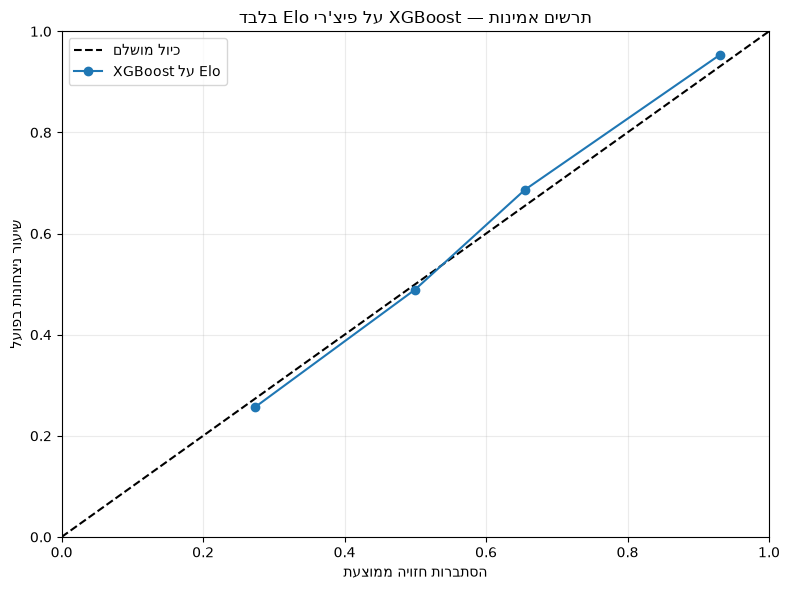

In [8]:
xgb_val_probability = elo_xgb_model.predict_proba(X_val)[:, 1]
xgb_val_prediction = (xgb_val_probability >= 0.5).astype(int)

xgb_val_accuracy = accuracy_score(y_val_symmetric, xgb_val_prediction)
xgb_val_log_loss = log_loss(y_val_symmetric, xgb_val_probability, labels=[0, 1])
xgb_val_brier = brier_score_loss(y_val_symmetric, xgb_val_probability)

print(f"דיוק XGBoost על Elo באימות: {xgb_val_accuracy:.6f}")
print(f"לוג־לוס XGBoost על Elo באימות: {xgb_val_log_loss:.6f}")
print(f"ציון ברייר XGBoost על Elo באימות: {xgb_val_brier:.6f}")

observed_rate, mean_probability = calibration_curve(
    y_val_symmetric, xgb_val_probability, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="כיול מושלם")
ax.plot(mean_probability, observed_rate, marker="o", label="XGBoost על Elo")
ax.set_title("תרשים אמינות — XGBoost על פיצ'רי Elo בלבד")
ax.set_xlabel("הסתברות חזויה ממוצעת")
ax.set_ylabel("שיעור ניצחונות בפועל")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Ablation Decision

The Elo-only result is recorded as the comparison point for all later candidate features and for the eventual canonical model selection.

## נקודת עצירה לאחר מחקר ההסרה

המודל בחר באיטרציה 169 והשיג באימות המסומטר דיוק של 0.624013, לוג־לוס של 0.624156 וציון ברייר של 0.218974. בהשוואה לקו הבסיס הגולמי, הירידה בלוג־לוס ובברייר מלמדת שעצי ההחלטה הצליחו למפות מחדש את אות ה־Elo להסתברויות שימושיות יותר. עם זאת, זהו עדיין מחקר הסרה על משפחת פיצ'רים יחידה ולא הוכחה לכיול מושלם; תרשים האמינות מאפשר לראות באילו תחומי הסתברות נשארה סטייה.

לא נוספו פיצ'רי DNA או שחקנים, לא בוצע כיול חיצוני ולא נעשה שימוש בחלוקת הבדיקה לצורך אימון, בחירת מודל או דיווח מדדים.